# Module 2: Sentiment & Emotion Classifier

This notebook trains a classifier to identify customer sentiment using a fine-tuned `distilbert-base-uncased` model. We leverage the `dair-ai/emotion` dataset, mapping its 6 raw emotions into 3 sentiment buckets (negative, neutral, positive) suitable for customer support.

In [1]:
# Disable tqdm progress bars to prevent ipykernel ContextVar errors
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
import datasets
datasets.disable_progress_bar()

import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Add src to path to import config
sys.path.append(os.path.abspath('..'))
from src.config import EMOTION_DATASET, SENTIMENT_MAP, SENTIMENT_LABELS, SENTIMENT_MODEL_DIR

# Set seaborn style for plots
sns.set_theme(style="whitegrid")

## 1. Load Dataset and Exploratory Data Analysis (EDA)

The `dair-ai/emotion` dataset contains Twitter messages labeled with one of 6 emotions:
- 0: sadness
- 1: joy
- 2: love
- 3: anger
- 4: fear
- 5: surprise

Let's load it and observe the severe class imbalance.

c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\acer\.cache\huggingface\hub\datasets--dair-ai--emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Sample texts:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


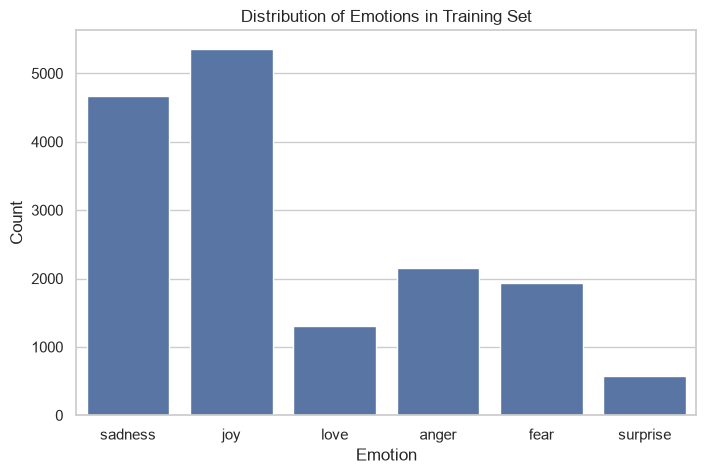

Class Distribution:
label
sadness     29.16250
joy         33.51250
love         8.15000
anger       13.49375
fear        12.10625
surprise     3.57500
Name: proportion, dtype: float64


In [2]:
# Load dataset
dataset = load_dataset(EMOTION_DATASET)
print("Dataset structure:")
print(dataset)

# Convert to pandas for EDA
train_df = pd.DataFrame(dataset['train'])
print("\nSample texts:")
display(train_df.head())

emotion_names = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
train_df['emotion_name'] = train_df['label'].map(emotion_names)

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='emotion_name', order=emotion_names.values())
plt.title('Distribution of Emotions in Training Set')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()

# Print percentages
print("Class Distribution:")
print((train_df['label'].value_counts(normalize=True) * 100).sort_index().rename(index=emotion_names))

## 2. Map 6 Emotions to 3 Sentiment Buckets

Customer support interactions are better modeled with three coarse classes: `negative`, `neutral`, and `positive`. We will map the 6 raw emotions as defined in `config.py`:
- `negative`: sadness, anger, fear
- `positive`: joy, love
- `neutral`: surprise

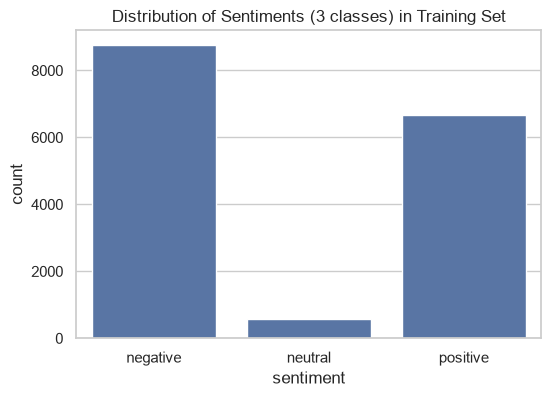

Sentiment Class Distribution:
sentiment
negative    54.7625
positive    41.6625
neutral      3.5750
Name: proportion, dtype: float64

Computed class weights: tensor([0.6087, 9.3240, 0.8001])


In [3]:
# Reverse map for labels -> IDs
label2id = {label: i for i, label in enumerate(SENTIMENT_LABELS)}
id2label = {i: label for i, label in enumerate(SENTIMENT_LABELS)}

def map_sentiment(example):
    original_emotion = example['label']
    sentiment_str = SENTIMENT_MAP[original_emotion]
    example['label'] = label2id[sentiment_str]
    return example

# Apply mapping to all splits
mapped_dataset = dataset.map(map_sentiment)

# Check new distribution on train set
mapped_train_df = pd.DataFrame(mapped_dataset['train'])
mapped_train_df['sentiment'] = mapped_train_df['label'].map(id2label)

plt.figure(figsize=(6, 4))
sns.countplot(data=mapped_train_df, x='sentiment', order=SENTIMENT_LABELS)
plt.title('Distribution of Sentiments (3 classes) in Training Set')
plt.show()

print("Sentiment Class Distribution:")
print((mapped_train_df['sentiment'].value_counts(normalize=True) * 100))

# Calculate class weights to handle imbalance during training
class_counts = mapped_train_df['label'].value_counts().sort_index().values
total_samples = len(mapped_train_df)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(f"\nComputed class weights: {class_weights}")

## 3. Fine-Tune `distilbert-base-uncased`

We'll use a pre-trained DistilBERT model. We must address the class imbalance by creating a custom Trainer that uses a weighted loss function.

In [ ]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = mapped_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=3, 
    id2label=id2label, 
    label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        # Use our pre-computed class weights
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./results_sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none" # disable wandb/tensorboard for clean notebook execution
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

# Uncomment the line below to actually run training
trainer.train()

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't 

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.134541,0.116821,0.970500,0.971812


c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


## 4. Evaluation

Let's evaluate the model on the held-out test set to get the accuracy, F1 score, and look at the confusion matrix.

In [ ]:
# Uncomment the lines below to evaluate after training
predictions_output = trainer.predict(tokenized_datasets["test"])
 y_pred = np.argmax(predictions_output.predictions, axis=1)
 y_true = predictions_output.label_ids

 print("Test Metrics:")
 print(predictions_output.metrics)

 print("\nClassification Report:")
 print(classification_report(y_true, y_pred, target_names=SENTIMENT_LABELS))

 cm = confusion_matrix(y_true, y_pred)
 plt.figure(figsize=(6, 4))
 sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=SENTIMENT_LABELS, yticklabels=SENTIMENT_LABELS)
 plt.xlabel('Predicted')
 plt.ylabel('True')
 plt.title('Confusion Matrix')
 plt.show()

IndentationError: unexpected indent (2966598545.py, line 2)

## 5. Save the Fine-Tuned Model

Save the model and tokenizer to the configured model directory so they can be loaded by the deployment module.

In [8]:
# Uncomment to save the model after training
 os.makedirs(SENTIMENT_MODEL_DIR, exist_ok=True)
 model.save_pretrained(SENTIMENT_MODEL_DIR)
 tokenizer.save_pretrained(SENTIMENT_MODEL_DIR)
 print(f"Model and tokenizer saved to {SENTIMENT_MODEL_DIR}")

IndentationError: unexpected indent (1245625753.py, line 2)

## 6. Qualitative Testing and Domain Shift

The `dair-ai/emotion` dataset is comprised of Twitter messages, which differ in style from e-commerce customer support queries. This is known as a **domain shift**. 
- Twitter data often contains slang, emojis, and expressive personal statements.
- Customer support messages are usually transactional, formal, and goal-oriented.

**Mitigation Strategies:**
1. Zero-shot or few-shot tuning with actual customer support data if available.
2. Continual fine-tuning: Collect interactions from the live chatbot, manually label a small high-quality subset, and fine-tune.
3. Prompt engineering: Using an LLM to override the sentiment if the classifier's confidence is low.

Let's test the model (using the untuned base for now, or the fine-tuned one if training was run) on some simulated customer support messages to see how it handles the domain.

In [ ]:
def test_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze(0)
    pred_idx = torch.argmax(probs).item()
    confidence = probs[pred_idx].item()
    return id2label[pred_idx], confidence

test_messages = [
    "I am absolutely furious about this order delay!",
    "Thanks for the quick delivery, very happy!",
    "I need to check my order status."
]

print("Qualitative Tests on Customer Support Messages:\n")
for msg in test_messages:
    pred, conf = test_sentiment(msg)
    print(f"Message: '{msg}'")
    print(f"Prediction: {pred} (Confidence: {conf:.2f})\n")